# Datathon Passos Mágicos - Análise Exploratória e Storytelling

Este notebook responde às 11 perguntas do desafio com base na base consolidada analítica e, quando necessário, na base reduzida para modelagem.

## Objetivos
- Entender a evolução dos indicadores pedagógicos, psicossociais e de engajamento;
- Identificar padrões de risco de defasagem;
- Avaliar a efetividade do programa ao longo dos anos e fases;
- Preparar insumos para o modelo preditivo e para o storytelling da apresentação final.

## Bases utilizadas
- Base analítica consolidada: `base_PEDE_consolidada_analitica.parquet`
- Base reduzida para ML: `base_processada_reduzida_ML.parquet`

In [1]:
# 2) Imports e configuraçãoimport warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [2]:
# 3) Carga das bases
df = pd.read_parquet("../data/processed/base_PEDE_consolidada_analitica.parquet")
df_ml = pd.read_parquet("../data/processed/base_processada_reduzida_ML.parquet")

print("Base analítica:", df.shape)
print("Base ML:", df_ml.shape)

display(df.head())
display(df_ml.head())


Base analítica: (3030, 55)
Base ML: (3030, 18)


,ano_pede,ra,fase,turma,nome,ano_nasc,data_nasc,idade,genero,ano_ingresso,instituicao_ensino,escola,ativo_inativo,pedra_2020,pedra_2021,pedra_2022,pedra_2023,pedra_2024,inde_2022,inde_2023,inde_2024,cg,cf,ct,n_av,avaliador_1,rec_av1,avaliador_2,rec_av2,avaliador_3,rec_av3,avaliador_4,rec_av4,avaliador_5,rec_av5,avaliador_6,rec_av6,iaa,ieg,ips,ipp,rec_psicologia,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,destaque_ieg,destaque_ida,destaque_ipv
0,2022,RA-1,7,A,Aluno-1,2003.0,NaT,19.0,Menina,2016,Escola Pública,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.783,NaN,NaN,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.3,4.1,5.6,NaN,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,2022,RA-2,7,A,Aluno-2,2005.0,NaT,17.0,Menina,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.055,NaN,NaN,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,8.8,5.2,6.3,NaN,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,2022,RA-3,7,A,Aluno-3,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ágata,<NA>,<NA>,6.591,NaN,NaN,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,0.0,7.9,5.6,NaN,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,2022,RA-4,7,A,Aluno-4,2005.0,NaT,17.0,Menino,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.951,NaN,NaN,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.8,4.5,5.6,NaN,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,2022,RA-5,7,A,Aluno-5,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.427,NaN,NaN,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,7.9,8.6,5.6,NaN,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


,ra,ano_pede,inde,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,defasagem_ano_seguinte,risco_defasagem_futuro
0,RA-1,2022,5.783000,4.0,8.3,4.1,5.6,NaN,4.0,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1,0.0,0
1,RA-1,2023,5.783000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,None,0,0.0,0
2,RA-1,2024,5.783133,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,None,0,NaN,<NA>
3,RA-10,2022,5.784000,4.0,8.3,5.2,5.0,NaN,4.1,3.3,2.6,6.4,7.056,5.0,Fase 8 (Universitários),-1,NaN,<NA>
4,RA-100,2022,7.618000,4.0,8.8,7.8,5.0,NaN,7.6,7.0,7.8,8.1,7.250,10.0,Fase 3 (7º e 8º ano),1,NaN,<NA>


In [3]:
for ano in sorted(df["ano_pede"].dropna().unique()):
    print(f"\nANO {ano}")
    print("FASE:", sorted(df.loc[df["ano_pede"] == ano, "fase"].dropna().unique()))
    print("TURMA:", sorted(df.loc[df["ano_pede"] == ano, "turma"].dropna().unique()))


ANO 2022
FASE: ['0', '1', '2', '3', '4', '5', '6', '7']
TURMA: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z']

ANO 2023
FASE: ['0', '1', '2', '3', '4', '5', '6', '7', '8']
TURMA: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'Y']

ANO 2024
FASE: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
TURMA: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'Y']


In [4]:
# 4) Padronizações auxiliares
# cria coluna inde única na base analítica
df["inde"] = np.nan

if "inde_2022" in df.columns:
    df.loc[df["ano_pede"] == 2022, "inde"] = df["inde_2022"]
if "inde_2023" in df.columns:
    df.loc[df["ano_pede"] == 2023, "inde"] = df["inde_2023"]
if "inde_2024" in df.columns:
    df.loc[df["ano_pede"] == 2024, "inde"] = df["inde_2024"]

# garantir numéricos
cols_numericas = [
    "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
    "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
]

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# categorias úteis
for col in ["fase", "turma", "genero", "instituicao_ensino", "pedra_2022", "pedra_2023", "pedra_2024"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ano_pede            3030 non-null   int64         
 1   ra                  3030 non-null   string        
 2   fase                3030 non-null   string        
 3   turma               2992 non-null   string        
 4   nome                3030 non-null   string        
 5   ano_nasc            860 non-null    float64       
 6   data_nasc           2170 non-null   datetime64[ns]
 7   idade               2631 non-null   float64       
 8   genero              3030 non-null   string        
 9   ano_ingresso        3030 non-null   int64         
 10  instituicao_ensino  3029 non-null   string        
 11  escola              1155 non-null   string        
 12  ativo_inativo       0 non-null      string        
 13  pedra_2020          754 non-null    string      

In [5]:
# 5) Funções auxiliares
def plot_bar(data, x, y, title, figsize=(10,5), rotation=0):
    plt.figure(figsize=figsize)
    sns.barplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_line(data, x, y, hue=None, title="", figsize=(10,5), rotation=0, marker="o"):
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_heatmap_corr(df_corr, title="Mapa de Correlação"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def categorizar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor <= 0:
        return "Sem defasagem"
    elif valor == 1:
        return "Defasagem leve"
    elif valor == 2:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"

### 1. Adequação do nível (IAN)

,categoria,qtd_alunos
0,Sem defasagem,2839
1,Defasagem leve,165
2,Defasagem moderada,24
3,Defasagem severa,2


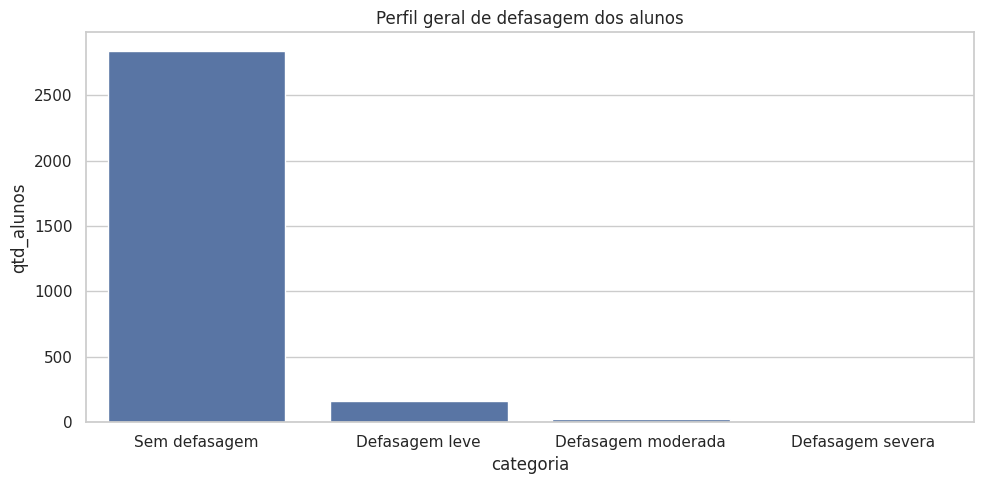

In [6]:
# 6) Perfil geral de defasagem
# se existir a coluna defasagem, usamos ela; se não, podemos usar IAN ajustado
if "defasagem" in df.columns:
    df["categoria_defasagem"] = df["defasagem"].apply(categorizar_defasagem)
else:
    # fallback usando ian
    # ajuste se a lógica do seu projeto usar outra convenção
    df["defasagem_proxy"] = df["ian"].abs()
    df["categoria_defasagem"] = df["defasagem_proxy"].apply(categorizar_defasagem)

perfil_def = (
    df["categoria_defasagem"]
    .value_counts(dropna=False)
    .rename_axis("categoria")
    .reset_index(name="qtd_alunos")
)

display(perfil_def)

plot_bar(
    perfil_def,
    x="categoria",
    y="qtd_alunos",
    title="Perfil geral de defasagem dos alunos"
)

,ano_pede,categoria_defasagem,qtd_alunos
0,2022,Defasagem leve,9
1,2022,Defasagem moderada,3
2,2022,Sem defasagem,848
3,2023,Defasagem leve,37
4,2023,Defasagem moderada,5
5,2023,Sem defasagem,972
6,2024,Defasagem leve,119
7,2024,Defasagem moderada,16
8,2024,Defasagem severa,2
9,2024,Sem defasagem,1019


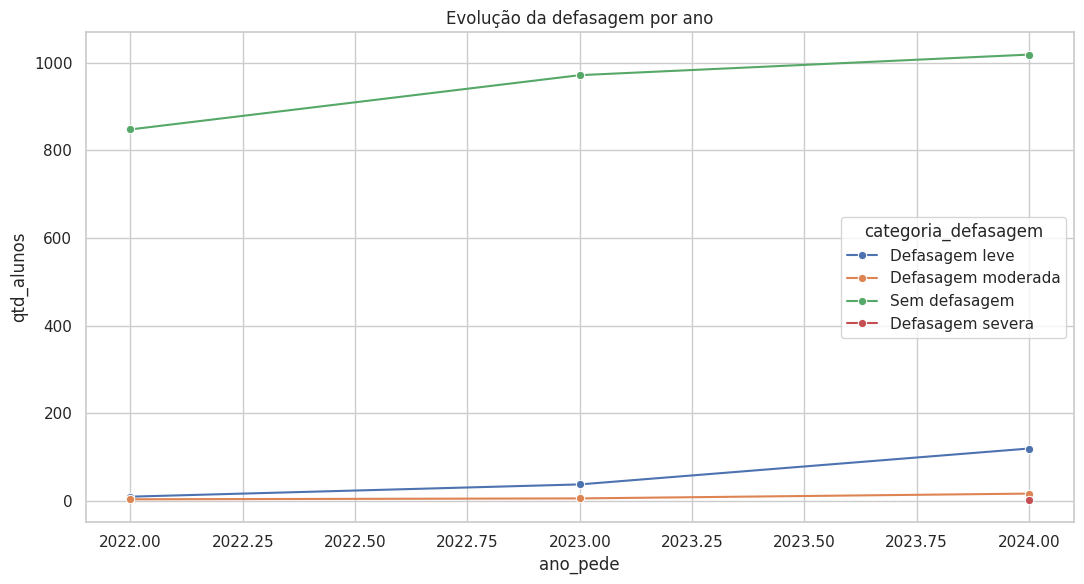

In [7]:
# 7) Evolução da defasagem ao longo dos anos
evol_def = (
    df.groupby(["ano_pede", "categoria_defasagem"])
      .size()
      .reset_index(name="qtd_alunos")
)

display(evol_def.head(20))

plot_line(
    evol_def,
    x="ano_pede",
    y="qtd_alunos",
    hue="categoria_defasagem",
    title="Evolução da defasagem por ano",
    figsize=(11,6)
)

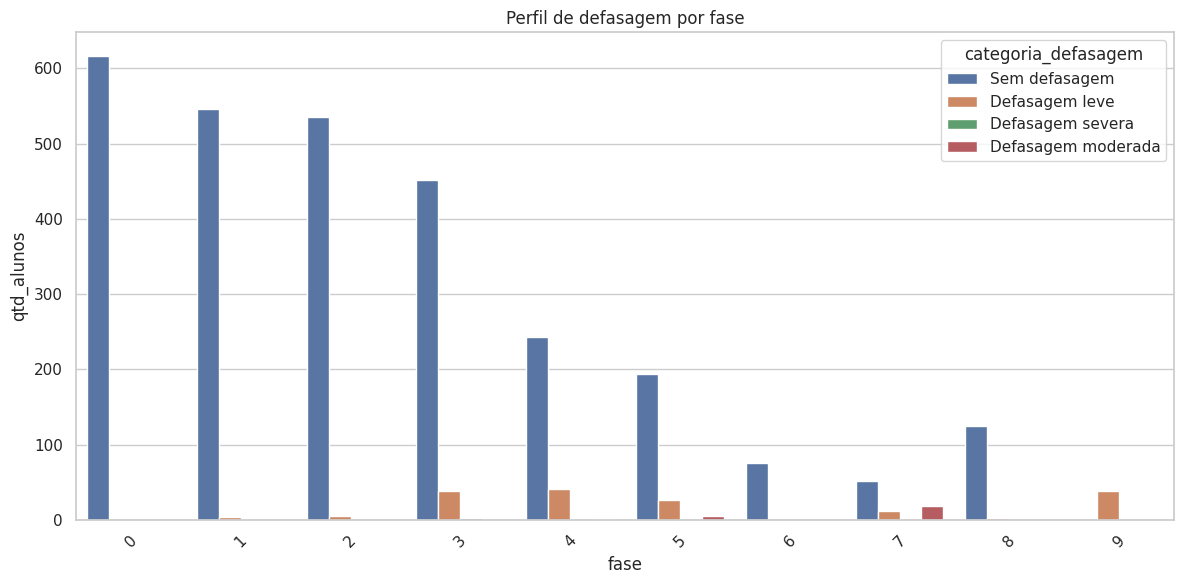

In [8]:
# 8) Defasagem por fase
if "fase" in df.columns:
    def_fase = (
        df.groupby(["fase", "categoria_defasagem"])
          .size()
          .reset_index(name="qtd_alunos")
    )

    plt.figure(figsize=(12,6))
    sns.barplot(data=def_fase, x="fase", y="qtd_alunos", hue="categoria_defasagem")
    plt.title("Perfil de defasagem por fase")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Leitura analítica
- Esta seção mostra quantos alunos estão sem defasagem, com defasagem leve, moderada ou severa.
- A evolução por ano ajuda a verificar se o programa está conseguindo reduzir casos moderados e severos.
- A análise por fase permite identificar em quais etapas da jornada os alunos concentram maior vulnerabilidade.

### 2. Desempenho acadêmico (IDA)

,ano_pede,ida_medio
0,2022,6.092907
1,2023,6.663394
2,2024,6.351422


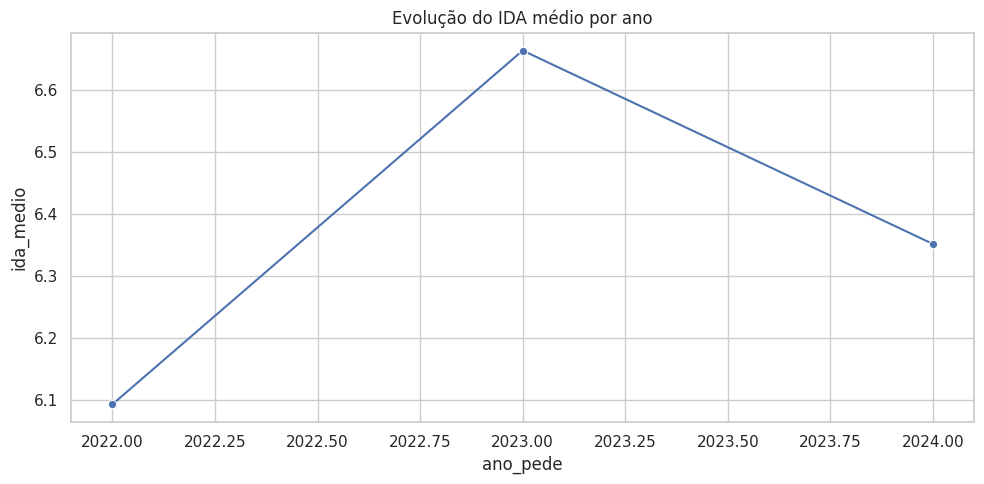

In [9]:
# 10) IDA médio por ano
ida_ano = (
    df.groupby("ano_pede", as_index=False)["ida"]
      .mean()
      .rename(columns={"ida": "ida_medio"})
)

display(ida_ano)

plot_line(
    ida_ano,
    x="ano_pede",
    y="ida_medio",
    title="Evolução do IDA médio por ano"
)

,ano_pede,fase,ida_medio
0,2022,0,7.140000
1,2022,1,6.464062
2,2022,2,5.406452
3,2022,3,5.141892
4,2022,4,6.052632
5,2022,5,5.873333
6,2022,6,6.694444
7,2022,7,5.252381
8,2023,0,7.422078
9,2023,1,6.814451


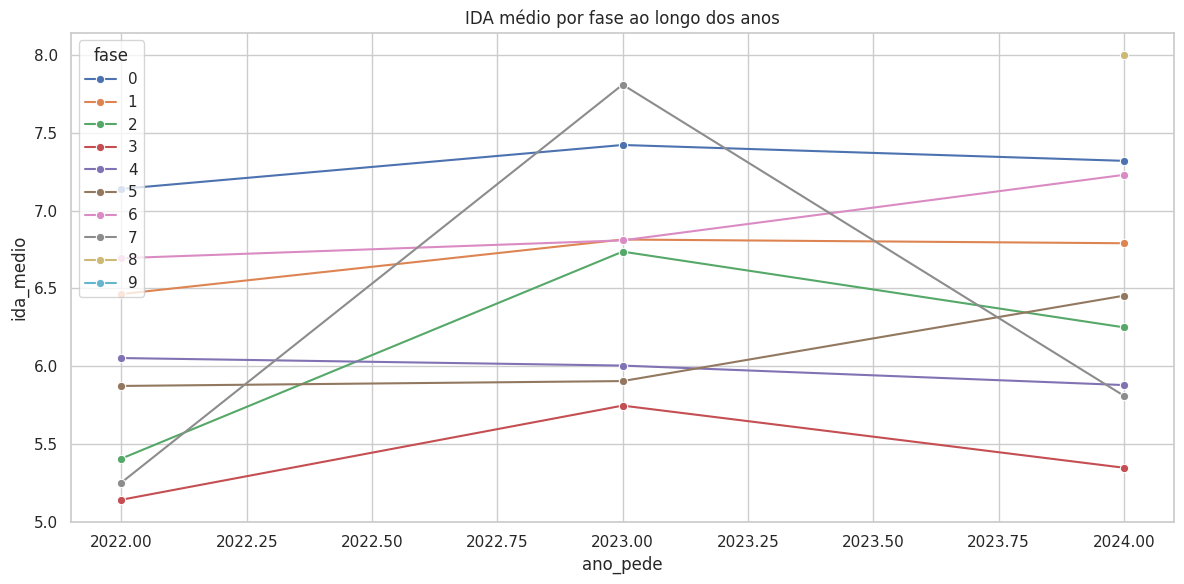

In [10]:
#11) IDA médio por fase e ano
if "fase" in df.columns:
    ida_fase_ano = (
        df.groupby(["ano_pede", "fase"], as_index=False)["ida"]
          .mean()
          .rename(columns={"ida": "ida_medio"})
    )

    display(ida_fase_ano.head(20))

    plot_line(
        ida_fase_ano,
        x="ano_pede",
        y="ida_medio",
        hue="fase",
        title="IDA médio por fase ao longo dos anos",
        figsize=(12,6)
    )

### Leitura analítica
- Se o IDA médio sobe entre 2022 e 2024, há evidência de melhora acadêmica.
- Se algumas fases melhoram mais do que outras, o programa pode estar sendo mais efetivo em etapas específicas.
- A decomposição por disciplinas ajuda a entender onde estão os maiores ganhos ou gargalos.

# Conclusões finais

## Principais achados
1. O perfil de defasagem mostra onde estão os alunos mais vulneráveis e como isso evolui entre os anos.
2. O desempenho acadêmico pode ser acompanhado por fase, ano e disciplina, revelando melhorias ou estagnações.
3. O engajamento aparece como variável-chave, com relação importante com desempenho e ponto de virada.
4. Autoavaliação, aspectos psicossociais e psicopedagógicos ajudam a explicar diferenças de trajetória entre alunos.
5. O modelo preditivo oferece uma base concreta para ação preventiva, identificando probabilidade de risco antes da piora observada.

## Recomendações para a Passos Mágicos
- Intensificar ações preventivas para grupos com baixa combinação de IDA, IEG, IPS e IPP;
- Criar alertas precoces no app com base na probabilidade de risco;
- Priorizar fases e perfis onde a defasagem é mais persistente;
- Combinar indicadores quantitativos com recomendações qualitativas dos avaliadores.

## Próximos passos
- Refinar o modelo no notebook de ML;
- Construir dashboard e app em Streamlit;
- Transformar estes achados em storytelling executivo para o PPT/PDF final.